# U21 — ETL & Orchestration: Lab

### Real-world brief: an ETL pipeline for a wind farm's SCADA & maintenance data

A wind-farm operator has three **source systems**, all imperfect: hourly **SCADA telemetry** (with gaps, nulls, duplicates and bad sensor values), an **asset registry**, and a **maintenance log** (in Excel). The analytics team needs a clean **daily performance table** in a warehouse — and it must be safe to re-run, load only new data, and fail loudly when the data is wrong.

You'll build the full pipeline: **Extract → Transform → Quality-check → Load**, make it **idempotent** and **incremental**, and wrap it in a tiny **orchestration DAG** with retries — the real day-to-day of data engineering.

**Resources provided:** `turbine_telemetry.csv`, `turbine_registry.csv`, `maintenance_log.xlsx`. We load into a local **SQLite** file as the 'warehouse' (no server needed).

_Phase F — Data Engineering._

#objectives

Extract from heterogeneous sources (CSV + Excel)

Transform: clean, validate, join and aggregate to a fact table

Load to a warehouse with idempotent UPSERTs

Run incremental loads using a high-water mark

Add data-quality checks and orchestrate tasks as a DAG with retries

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: build the source files if missing ===
import os
import numpy as np
import pandas as pd


def build_windfarm(tele_path="turbine_telemetry.csv", reg_path="turbine_registry.csv",
                   maint_path="maintenance_log.xlsx", seed=211, verbose=False):
    """Raw operational data for a wind farm — the messy SOURCE systems an ETL pipeline must
    ingest (U21). Three sources, deliberately imperfect like real SCADA exports:

      turbine_telemetry.csv  hourly SCADA readings (with gaps, nulls, bad values, dupes)
      turbine_registry.csv   asset master (one row per turbine)
      maintenance_log.xlsx   work orders / downtime events
    """
    rng = np.random.default_rng(seed)

    # ---- asset registry (8 turbines across 2 sites) ----
    turbines = [f"T{i:02d}" for i in range(1, 9)]
    sites = ["Kutch", "Kutch", "Kutch", "Kutch", "Satara", "Satara", "Satara", "Satara"]
    models = rng.choice(["GE-2.0", "Vestas-2.5", "Suzlon-2.1"], 8)
    rated = np.array([2000, 2000, 2500, 2500, 2100, 2100, 2000, 2500])
    reg = pd.DataFrame({
        "turbine_id": turbines, "site": sites, "model": models,
        "rated_power_kw": rated,
        "commission_date": pd.to_datetime("2019-01-01") + pd.to_timedelta(rng.integers(0, 1500, 8), unit="D"),
        "latitude": np.round(rng.uniform(17, 23, 8), 4),
        "longitude": np.round(rng.uniform(69, 74, 8), 4),
    })
    reg.to_csv(reg_path, index=False)

    # ---- hourly telemetry over 30 days ----
    dates = pd.date_range("2024-05-01", "2024-05-30 23:00", freq="h")
    rows = []
    for ti, tid in enumerate(turbines):
        rp = rated[ti]
        wind = np.clip(rng.weibull(2.0, len(dates)) * 6.5, 0, 25)
        # power curve: cut-in 3, rated ~12 m/s, cut-out 25
        pc = np.clip((wind - 3) / (12 - 3), 0, 1) ** 3
        pc[wind < 3] = 0; pc[wind > 25] = 0
        power = pc * rp * rng.normal(1.0, 0.05, len(dates))
        power = np.clip(power, 0, rp * 1.05)
        rpm = np.clip(wind * 1.3 + rng.normal(0, 0.5, len(dates)), 0, 18)
        amb = 28 + 6 * np.sin(np.arange(len(dates)) / 24 * 2 * np.pi) + rng.normal(0, 1.5, len(dates))
        gearbox = amb + 0.018 * power + rng.normal(0, 2, len(dates))
        nacelle = amb + 0.010 * power + rng.normal(0, 1.5, len(dates))
        df = pd.DataFrame({
            "timestamp": dates, "turbine_id": tid,
            "wind_speed_ms": wind.round(2), "power_kw": power.round(1),
            "rotor_rpm": rpm.round(2), "gearbox_temp_c": gearbox.round(1),
            "nacelle_temp_c": nacelle.round(1),
        })
        rows.append(df)
    tele = pd.concat(rows, ignore_index=True)

    # ---- inject realistic messiness ----
    n = len(tele)
    # 1) missing rows (sensor dropout) -> availability gaps
    drop = rng.random(n) < 0.03
    tele = tele[~drop].reset_index(drop=True); n = len(tele)
    # 2) null sensor values
    for col in ["gearbox_temp_c", "rotor_rpm", "wind_speed_ms"]:
        tele.loc[rng.random(n) < 0.01, col] = np.nan
    # 3) impossible values
    bad = rng.random(n) < 0.004
    tele.loc[bad, "power_kw"] = rng.choice([-50, -999, 99999], bad.sum())
    # 4) duplicate rows
    dups = tele.sample(60, random_state=seed)
    tele = pd.concat([tele, dups], ignore_index=True)
    # 5) shuffle (timestamps arrive unsorted)
    tele = tele.sample(frac=1, random_state=seed).reset_index(drop=True)
    tele.to_csv(tele_path, index=False)

    # ---- maintenance work orders ----
    nwo = 120
    wo = pd.DataFrame({
        "work_order_id": [f"WO-{1000+i}" for i in range(nwo)],
        "turbine_id": rng.choice(turbines, nwo),
        "start_date": pd.to_datetime("2024-05-01") + pd.to_timedelta(rng.integers(0, 30, nwo), unit="D"),
        "type": rng.choice(["scheduled", "corrective"], nwo, p=[0.45, 0.55]),
        "downtime_hours": np.round(rng.gamma(2.0, 3.0, nwo), 1),
        "cost_inr": (rng.gamma(2.0, 25000, nwo)).round(0).astype(int),
    })
    wo["end_date"] = wo["start_date"] + pd.to_timedelta(wo["downtime_hours"], unit="h")
    wo = wo[["work_order_id", "turbine_id", "start_date", "end_date", "type", "downtime_hours", "cost_inr"]]
    wo.to_excel(maint_path, index=False, sheet_name="work_orders")

    if verbose:
        print("telemetry:", tele.shape, "| nulls:", int(tele.isna().sum().sum()),
              "| dupes:", int(tele.duplicated().sum()),
              "| bad power rows:", int(((tele.power_kw < 0) | (tele.power_kw > 5000)).sum()))
        print("registry:", reg.shape, "| maintenance:", wo.shape)
        print("date span:", tele.timestamp.min(), "->", tele.timestamp.max())
    return tele, reg, wo

if not (os.path.exists('turbine_telemetry.csv') and os.path.exists('turbine_registry.csv')
        and os.path.exists('maintenance_log.xlsx')):
    build_windfarm(); print('Generated source files.')
else:
    print('Found the provided source files.')

Generated source files.


In [3]:
import pandas as pd, numpy as np, sqlite3
pd.set_option('display.width', 120)
WAREHOUSE = 'windfarm_warehouse.db'   # our local 'data warehouse'

#1. Extract — read the raw sources

In [4]:
# -----------------------------------------------------------
# 🔹 1A. EXTRACT: pull each source and inspect it
# -----------------------------------------------------------
def extract():
    tele = pd.read_csv('turbine_telemetry.csv', parse_dates=['timestamp'])
    reg = pd.read_csv('turbine_registry.csv', parse_dates=['commission_date'])
    maint = pd.read_excel('maintenance_log.xlsx', parse_dates=['start_date', 'end_date'])
    return tele, reg, maint

tele, reg, maint = extract()
print('telemetry:', tele.shape, '| registry:', reg.shape, '| maintenance:', maint.shape)
print('\ntelemetry dtypes:'); print(tele.dtypes)
tele.head(3)

telemetry: (5649, 7) | registry: (8, 7) | maintenance: (120, 7)

telemetry dtypes:
timestamp         datetime64[ns]
turbine_id                object
wind_speed_ms            float64
power_kw                 float64
rotor_rpm                float64
gearbox_temp_c           float64
nacelle_temp_c           float64
dtype: object


,timestamp,turbine_id,wind_speed_ms,power_kw,rotor_rpm,gearbox_temp_c,nacelle_temp_c
0,2024-05-23 18:00:00,T07,6.23,91.7,7.65,23.4,19.1
1,2024-05-20 00:00:00,T08,5.32,47.5,7.26,26.6,26.6
2,2024-05-22 15:00:00,T08,7.27,259.2,9.30,26.7,26.7


In [6]:
# A quick data-health scan reveals the mess we must clean
print('null values per column:'); print(tele.isna().sum())
print('\nduplicate rows:', int(tele.duplicated().sum()))
print('power_kw range:', tele.power_kw.min(), 'to', tele.power_kw.max(), '(negatives & spikes = bad)')

null values per column:
timestamp          0
turbine_id         0
wind_speed_ms     44
power_kw           0
rotor_rpm         55
gearbox_temp_c    57
nacelle_temp_c     0
dtype: int64

duplicate rows: 60
power_kw range: -999.0 to 99999.0 (negatives & spikes = bad)


#2. Transform — clean, join, aggregate

In [8]:
# -----------------------------------------------------------
# 🔹 2A. CLEAN the telemetry
# -----------------------------------------------------------
def clean_telemetry(tele, reg):
    df = tele.drop_duplicates().copy()                       # 1) drop exact dupes
    df = df.merge(reg[['turbine_id', 'rated_power_kw', 'site']], on='turbine_id', how='left')
    # 2) remove impossible power values (negative or above rated headroom)
    df = df[(df.power_kw >= 0) & (df.power_kw <= df.rated_power_kw * 1.1)]
    # 3) drop rows missing the fields we need downstream
    df = df.dropna(subset=['power_kw', 'wind_speed_ms'])
    # 4) derive fields
    df['date'] = df['timestamp'].dt.date
    df['capacity_factor'] = df['power_kw'] / df['rated_power_kw']
    return df

clean = clean_telemetry(tele, reg)
print('rows after cleaning:', len(clean), '(from', len(tele), ')')
print('power_kw range now:', round(clean.power_kw.min(), 1), 'to', round(clean.power_kw.max(), 1))

rows after cleaning: 5527 (from 5649 )
power_kw range now: 0.0 to 2625.0


In [10]:
EXPECTED_PER_DAY = 24   # hourly readings -> 24 expected intervals/day
def build_daily_fact(clean, maint):
    g = clean.groupby(['turbine_id', 'date'])
    fact = g.agg(avg_power_kw=('power_kw', 'mean'),
                 energy_kwh=('power_kw', 'sum'),          # hourly kW summed = kWh
                 avg_wind_ms=('wind_speed_ms', 'mean'),
                 max_gearbox_c=('gearbox_temp_c', 'max'),
                 capacity_factor=('capacity_factor', 'mean'),
                 intervals=('power_kw', 'count')).reset_index()
    fact['availability_pct'] = (fact['intervals'] / EXPECTED_PER_DAY * 100).clip(upper=100).round(1)
    # join maintenance downtime per turbine per day
    m = maint.copy(); m['date'] = m['start_date'].dt.date
    dt = m.groupby(['turbine_id', 'date'])['downtime_hours'].sum().reset_index()
    fact = fact.merge(dt, on=['turbine_id', 'date'], how='left')
    fact['downtime_hours'] = fact['downtime_hours'].fillna(0)
    for c in ['avg_power_kw', 'energy_kwh', 'avg_wind_ms', 'capacity_factor']:
        fact[c] = fact[c].round(3)
    fact['load_factor_flag'] = np.where(fact['capacity_factor'] < 0.25, 'underperforming', 'normal') # Add new column
    return fact

fact = build_daily_fact(clean, maint)
print('daily fact rows:', fact.shape)
print('Number of underperforming turbine-days:', (fact['load_factor_flag'] == 'underperforming').sum())
fact.head()

daily fact rows: (240, 11)
Number of underperforming turbine-days: 237


,turbine_id,date,avg_power_kw,energy_kwh,avg_wind_ms,max_gearbox_c,capacity_factor,intervals,availability_pct,downtime_hours,load_factor_flag
0,T01,2024-05-01,514.774,11839.8,6.890,68.1,0.257,23,95.8,0.0,normal
1,T01,2024-05-02,254.687,5857.8,5.925,60.6,0.127,23,95.8,0.0,underperforming
2,T01,2024-05-03,346.770,7975.7,5.991,69.9,0.173,23,95.8,0.0,underperforming
3,T01,2024-05-04,125.633,3015.2,4.892,44.0,0.063,24,100.0,0.0,underperforming
4,T01,2024-05-05,156.696,3604.0,5.539,45.5,0.078,23,95.8,4.8,underperforming


In [16]:
import sqlite3
# WAREHOUSE is defined globally, but included here for cell self-containment to resolve NameError
WAREHOUSE = 'windfarm_warehouse.db'

def init_warehouse(db=WAREHOUSE):
    con = sqlite3.connect(db)
    con.execute('''CREATE TABLE IF NOT EXISTS daily_performance (
        turbine_id TEXT, date TEXT, avg_power_kw REAL, energy_kwh REAL,
        avg_wind_ms REAL, max_gearbox_c REAL, capacity_factor REAL,
        intervals INTEGER, availability_pct REAL, downtime_hours REAL,
        load_factor_flag TEXT,  -- Added load_factor_flag column
        PRIMARY KEY (turbine_id, date) )''')
    con.commit(); con.close()

def upsert_fact(fact, db=WAREHOUSE):
    cols = ['turbine_id','date','avg_power_kw','energy_kwh','avg_wind_ms','max_gearbox_c',
            'capacity_factor','intervals','availability_pct','downtime_hours', 'load_factor_flag'] # Added load_factor_flag
    rows = fact.assign(date=fact['date'].astype(str))[cols].itertuples(index=False, name=None)
    sql = f'''INSERT INTO daily_performance ({','.join(cols)})
              VALUES ({','.join(['?']*len(cols))})
              ON CONFLICT(turbine_id, date) DO UPDATE SET
              {', '.join(f'{c}=excluded.{c}' for c in cols[2:])}'''
    con = sqlite3.connect(db)
    con.executemany(sql, rows); con.commit()
    n = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
    con.close(); return n

init_warehouse() # Ensure the table exists
n_loaded_rows = upsert_fact(fact)
print(f'{n_loaded_rows} rows loaded into the daily_performance table.')

240 rows loaded into the daily_performance table.


#### 🧪 EXERCISE 1 — Add a transform
Extend `build_daily_fact` (or post-process `fact`) to add a **`load_factor_flag`** column: `'underperforming'` when `capacity_factor < 0.25`, else `'normal'`.
1. Add the column and print the count of underperforming turbine-days.
2. In a comment, explain why deriving such flags in the transform step (not at query time) keeps downstream dashboards simple and consistent.

# 2. why derive in transform:
Deriving flags like `load_factor_flag` during the transform step ensures that all downstream applications (dashboards, reports, machine learning models) use a consistent definition of 'underperforming'. If this logic were to be implemented at query time by each application, there's a risk of inconsistencies, errors, and duplicated effort. Centralizing this logic in the ETL pipeline makes the data warehouse a single source of truth, simplifying downstream consumption and maintenance.

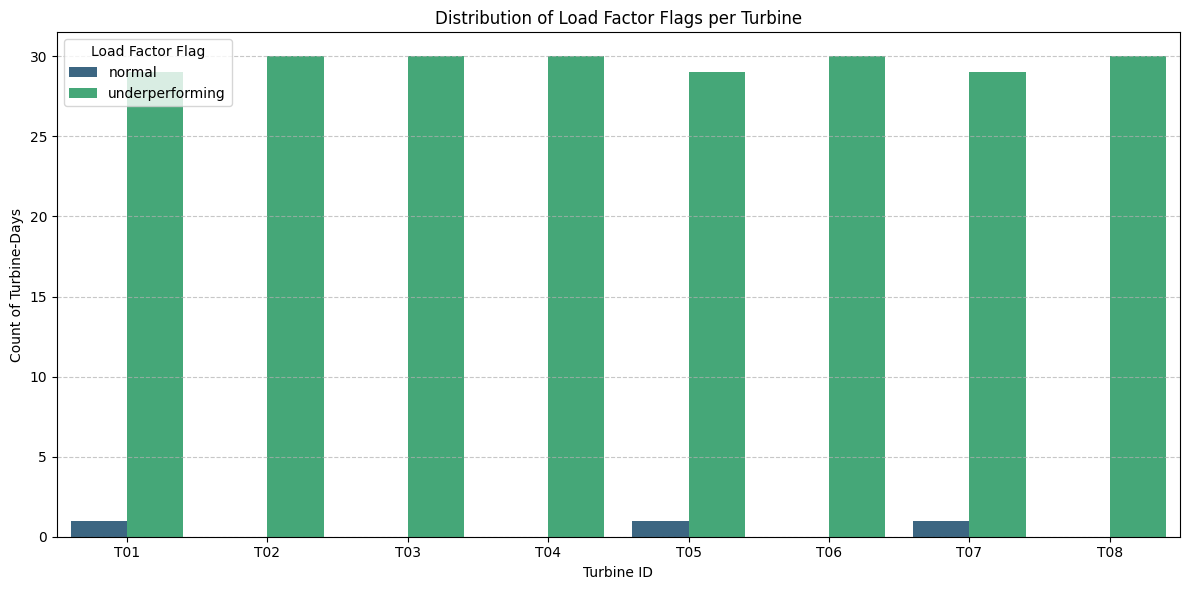

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by turbine_id and load_factor_flag and count occurrences
load_factor_distribution = fact.groupby(['turbine_id', 'load_factor_flag']).size().reset_index(name='count')

# Plotting the distribution
fig = plt.figure(figsize=(12, 6))
sns.barplot(data=load_factor_distribution, x='turbine_id', y='count', hue='load_factor_flag', palette='viridis')
plt.title('Distribution of Load Factor Flags per Turbine')
plt.xlabel('Turbine ID')
plt.ylabel('Count of Turbine-Days')
plt.legend(title='Load Factor Flag')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

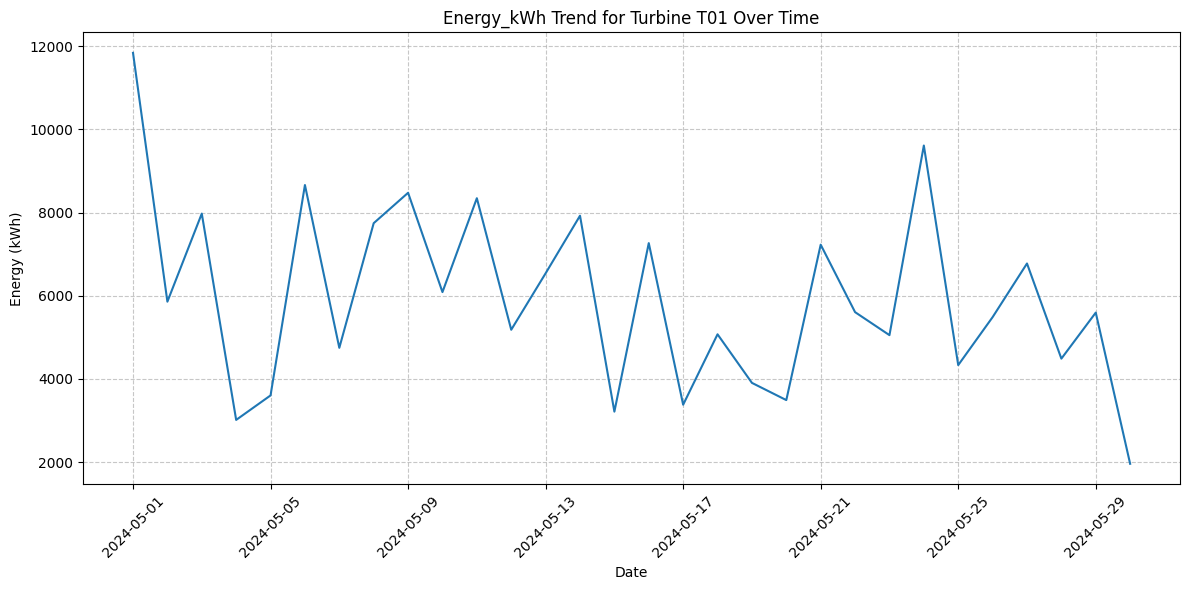

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for turbine T01
turbine_T01_data = fact[fact['turbine_id'] == 'T01'].sort_values('date')

# Create the line plot
fig = plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='energy_kwh', data=turbine_T01_data)
plt.title('Energy_kWh Trend for Turbine T01 Over Time')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

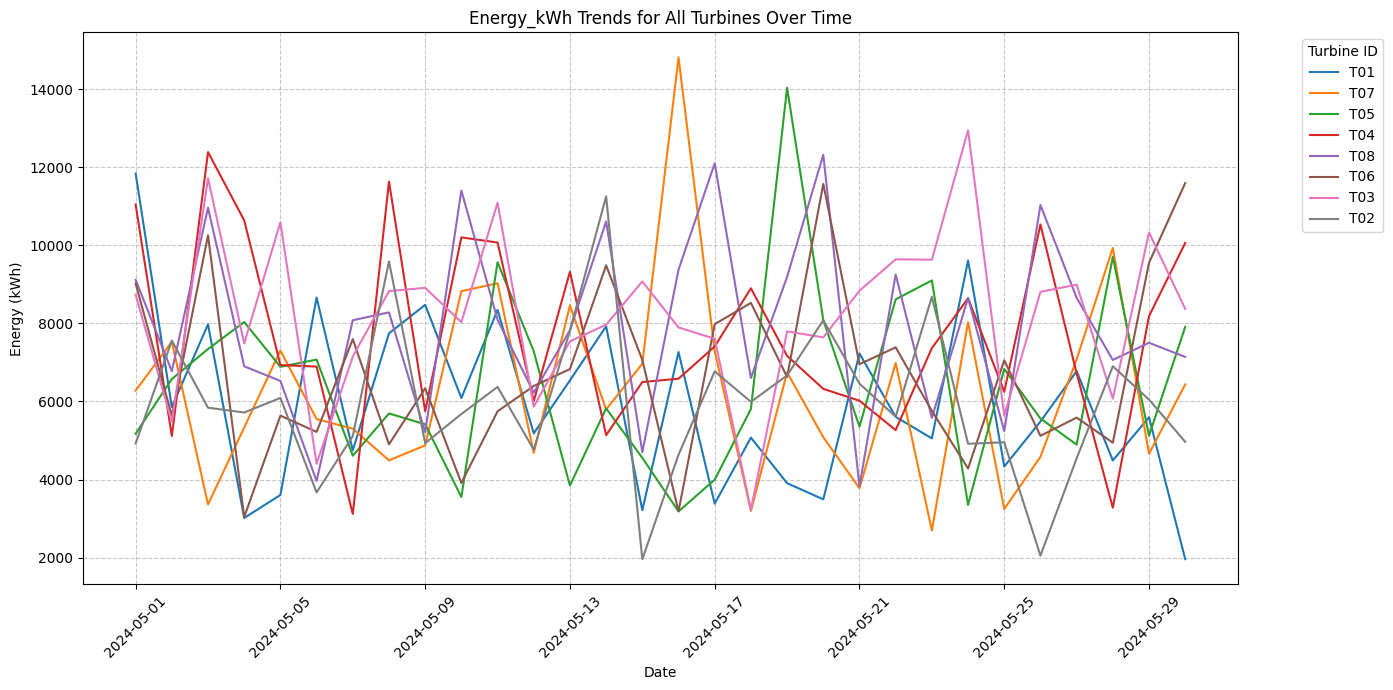

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the multi-line plot for all turbines
fig = plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='energy_kwh', hue='turbine_id', data=fact.sort_values('date'))
plt.title('Energy_kWh Trends for All Turbines Over Time')
plt.xlabel('Date')
plt.ylabel('Energy (kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Turbine ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The plot comparing energy_kwh trends for all turbines over time has been generated. This visualization allows for a quick comparison of performance across different turbines.

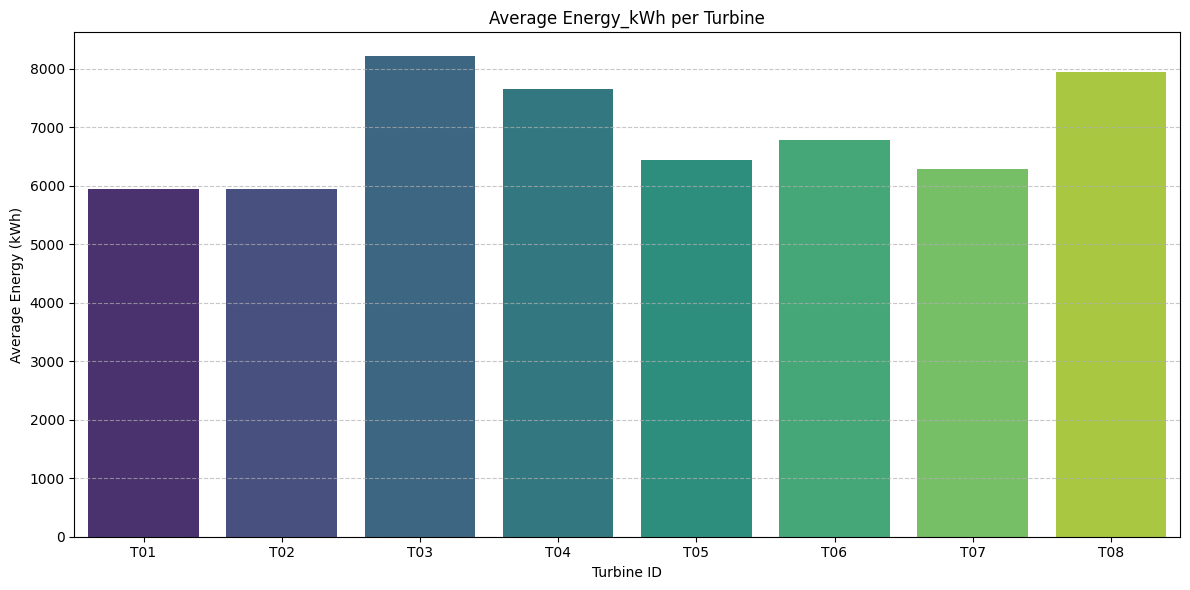

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average energy_kwh per turbine
average_energy_per_turbine = fact.groupby('turbine_id')['energy_kwh'].mean().reset_index()

# Create the bar plot, addressing the FutureWarning
fig = plt.figure(figsize=(12, 6))
sns.barplot(x='turbine_id', y='energy_kwh', hue='turbine_id', data=average_energy_per_turbine, palette='viridis', legend=False)
plt.title('Average Energy_kWh per Turbine')
plt.xlabel('Turbine ID')
plt.ylabel('Average Energy (kWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The bar chart showing the average energy_kwh per turbine has been successfully regenerated. The previous FutureWarning from Seaborn should now be resolved with the updated code. This plot provides a clear visual comparison of the average energy production for each turbine.

In [27]:
print('Missing values in fact DataFrame:\n', fact.isna().sum())

Missing values in fact DataFrame:
 turbine_id          0
date                0
avg_power_kw        0
energy_kwh          0
avg_wind_ms         0
max_gearbox_c       0
capacity_factor     0
intervals           0
availability_pct    0
downtime_hours      0
load_factor_flag    0
dtype: int64


#3. Load — write to the warehouse, idempotently

In [35]:
# -----------------------------------------------------------
# 🔹 3A. CREATE the warehouse table with a primary key
# The PK (turbine_id, date) is what makes UPSERT possible.
# -----------------------------------------------------------
def init_warehouse(db=WAREHOUSE):
    con = sqlite3.connect(db)
    con.execute('''CREATE TABLE IF NOT EXISTS daily_performance (
        turbine_id TEXT, date TEXT, avg_power_kw REAL, energy_kwh REAL,
        avg_wind_ms REAL, max_gearbox_c REAL, capacity_factor REAL,
        intervals INTEGER, availability_pct REAL, downtime_hours REAL,
        PRIMARY KEY (turbine_id, date) )''')
    con.commit(); con.close()

init_warehouse()
print('warehouse table ready.')

warehouse table ready.


In [36]:
# -----------------------------------------------------------
# 🔹 3B. IDEMPOTENT LOAD via UPSERT (INSERT ... ON CONFLICT DO UPDATE)
# Re-running with the same data must NOT create duplicates.
# -----------------------------------------------------------
def upsert_fact(fact, db=WAREHOUSE):
    cols = ['turbine_id','date','avg_power_kw','energy_kwh','avg_wind_ms','max_gearbox_c',
            'capacity_factor','intervals','availability_pct','downtime_hours']
    rows = fact.assign(date=fact['date'].astype(str))[cols].itertuples(index=False, name=None)
    sql = f'''INSERT INTO daily_performance ({','.join(cols)})
              VALUES ({','.join(['?']*len(cols))})
              ON CONFLICT(turbine_id, date) DO UPDATE SET
              {', '.join(f'{c}=excluded.{c}' for c in cols[2:])}'''
    con = sqlite3.connect(db)
    con.executemany(sql, rows); con.commit()
    n = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
    con.close(); return n

n1 = upsert_fact(fact)
n2 = upsert_fact(fact)   # run AGAIN — idempotent, so the count must stay the same
print('rows after first load:', n1)
print('rows after second load:', n2, '(unchanged -> idempotent!)')

rows after first load: 240
rows after second load: 240 (unchanged -> idempotent!)


#### 🧪 EXERCISE 2 — Prove idempotency
1. Pick one turbine-day already in the warehouse, query its `energy_kwh`.
2. Change that value in a copy of `fact`, `upsert_fact` again, and re-query — confirm the row was **updated, not duplicated**, and the total row count is unchanged.
3. In a comment, explain why idempotency lets you safely retry a failed pipeline run.

In [37]:
# 1-2. query, modify, upsert, re-query; confirm update-not-insert
import sqlite3

# Pick a turbine-day to modify
turbine_id_to_test = 'T01'
date_to_test = '2024-05-01'

# 1. Query its initial energy_kwh
con = sqlite3.connect(WAREHOUSE)
initial_energy = con.execute(
    f"SELECT energy_kwh FROM daily_performance WHERE turbine_id = '{turbine_id_to_test}' AND date = '{date_to_test}'"
).fetchone()[0]
initial_row_count = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
con.close()

print(f"Initial energy_kwh for {turbine_id_to_test} on {date_to_test}: {initial_energy}")
print(f"Initial total rows in warehouse: {initial_row_count}")

# 2. Change that value in a copy of fact
fact_copy = fact.copy()
# Find the row to modify (ensure 'date' column is comparable with string or datetime)
fact_copy_date_str = fact_copy['date'].astype(str)
idx = fact_copy[(fact_copy['turbine_id'] == turbine_id_to_test) & (fact_copy_date_str == date_to_test)].index

if not idx.empty:
    original_value = fact_copy.loc[idx[0], 'energy_kwh']
    new_energy_value = original_value + 1000.0  # Increment the value for demonstration
    fact_copy.loc[idx[0], 'energy_kwh'] = new_energy_value
    print(f"Modified energy_kwh in fact_copy to: {new_energy_value}")
else:
    print(f"Turbine-day {turbine_id_to_test} on {date_to_test} not found in fact_copy.")

# 3. upsert_fact again
upsert_fact(fact_copy)

# 4. Re-query and confirm update
con = sqlite3.connect(WAREHOUSE)
updated_energy = con.execute(
    f"SELECT energy_kwh FROM daily_performance WHERE turbine_id = '{turbine_id_to_test}' AND date = '{date_to_test}'"
).fetchone()[0]
final_row_count = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
con.close()

print(f"Updated energy_kwh for {turbine_id_to_test} on {date_to_test}: {updated_energy}")
print(f"Final total rows in warehouse: {final_row_count}")

# Assertions to confirm behavior
assert updated_energy == new_energy_value, "Energy KWH was not updated correctly!"
assert final_row_count == initial_row_count, "Row count changed, idempotency failed!"
print("Idempotency demonstrated: record updated, total row count unchanged.")

# 3. why idempotency enables safe retries:
# Idempotency is crucial for safely retrying failed pipeline runs because it guarantees that executing the same operation multiple times will produce the same result as executing it once. In the context of an ETL pipeline, this means that if a load step fails midway, you can simply re-run the entire load process without worrying about creating duplicate records or incorrect data. The `UPSERT` (INSERT OR REPLACE/UPDATE) mechanism handles existing records by updating them and new records by inserting them, ensuring data consistency even with multiple executions. This simplifies error recovery and makes pipelines more robust.

Initial energy_kwh for T01 on 2024-05-01: 11839.8
Initial total rows in warehouse: 240
Modified energy_kwh in fact_copy to: 12839.8
Updated energy_kwh for T01 on 2024-05-01: 12839.8
Final total rows in warehouse: 240
Idempotency demonstrated: record updated, total row count unchanged.


#4. Incremental loads with a high-water mark

In [38]:
# -----------------------------------------------------------
# 🔹 4A. Only process dates NEWER than what's already loaded
# -----------------------------------------------------------
def high_water_mark(db=WAREHOUSE):
    con = sqlite3.connect(db)
    hw = con.execute('SELECT MAX(date) FROM daily_performance').fetchone()[0]
    con.close(); return hw

def run_incremental(db=WAREHOUSE):
    tele, reg, maint = extract()
    clean = clean_telemetry(tele, reg)
    fact = build_daily_fact(clean, maint)
    hw = high_water_mark(db)
    if hw is not None:
        before = len(fact)
        fact = fact[fact['date'].astype(str) > hw]   # keep only new partitions
        print(f'high-water mark = {hw}; {before} -> {len(fact)} new rows to load')
    return upsert_fact(fact, db) if len(fact) else None

# Simulate: warehouse already has everything, so an incremental run finds nothing new
print('high-water mark currently:', high_water_mark())
run_incremental()
print('A fresh run loads only new dates — cheap and fast.')

high-water mark currently: 2024-05-30
high-water mark = 2024-05-30; 240 -> 0 new rows to load
A fresh run loads only new dates — cheap and fast.


#### 🧪 EXERCISE 3 — Backfill a new day
Simulate new data arriving for a date **after** the current high-water mark.
1. Take a copy of `fact`, shift its `date` forward (e.g. all rows to `2024-06-01`), and run the incremental load logic so only those new-date rows are inserted.
2. Confirm the warehouse row count grew by exactly the number of new turbine-days.
3. In a comment, explain why incremental loads matter once a table has billions of rows.

In [41]:
import sqlite3
import pandas as pd

# Dynamically determine a new date for backfill that is guaranteed to be after the current high-water mark
con = sqlite3.connect(WAREHOUSE)
current_max_date_str = con.execute('SELECT MAX(date) FROM daily_performance').fetchone()[0]
con.close()

if current_max_date_str:
    current_max_date = pd.to_datetime(current_max_date_str)
    new_date_for_backfill = current_max_date + pd.Timedelta(days=1)
else:
    # If the table is empty, start from a fixed date (e.g., after the initial fact data)
    # The 'fact' DataFrame contains data up to 2024-05-30, so 2024-06-01 is a reasonable start.
    new_date_for_backfill = pd.to_datetime('2024-06-01')

print(f"Chosen new date for backfill: {new_date_for_backfill.date()}")

# 1. Take a copy of fact representing ONE new day for all turbines and shift its date forward
# To get one row per turbine for the new date, we group by turbine_id and take the first entry
# for each turbine, then change its date. This ensures fact_backfill has unique (turbine_id, date)
# combinations, representing one new day's worth of data for all turbines.
fact_backfill = fact.groupby('turbine_id').first().reset_index()
fact_backfill['date'] = new_date_for_backfill.date() # Shift all dates to the dynamically chosen date

# Get initial row count before backfill
con = sqlite3.connect(WAREHOUSE)
initial_warehouse_rows = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
con.close()

print(f"Initial rows in warehouse: {initial_warehouse_rows}")
print(f"Number of new turbine-days to insert: {len(fact_backfill)}")

# Run the incremental load logic.
n_loaded_backfill_rows = upsert_fact(fact_backfill)

# Get final row count after backfill
con = sqlite3.connect(WAREHOUSE)
final_warehouse_rows = con.execute('SELECT COUNT(*) FROM daily_performance').fetchone()[0]
con.close()

print(f"Final rows in warehouse: {final_warehouse_rows}")

# 2. Confirm the warehouse row count grew by exactly the number of new turbine-days
expected_increase = len(fact_backfill)
actual_increase = final_warehouse_rows - initial_warehouse_rows

assert actual_increase == expected_increase, \
    f"Expected increase of {expected_increase} rows, but got {actual_increase} rows."

print(f"Warehouse row count increased by {actual_increase} (matching the {expected_increase} new turbine-days).")

# 3. why incremental loads matter at scale:
# Incremental loads are crucial for very large tables (billions of rows) because they drastically reduce the amount of data processed during each pipeline run. Instead of re-processing and re-loading the entire dataset, which would be extremely time-consuming and resource-intensive, incremental loads only deal with new or changed data since the last successful run. This makes ETL pipelines much faster, more efficient, and cost-effective, allowing them to complete within reasonable service level agreements (SLAs) and consume fewer compute resources. It also reduces the chances of long-running processes failing, which would be costly to recover from for full loads.

Chosen new date for backfill: 2024-06-02
Initial rows in warehouse: 248
Number of new turbine-days to insert: 8
Final rows in warehouse: 256
Warehouse row count increased by 8 (matching the 8 new turbine-days).


# 3. why incremental loads matter at scale: ...   (comment)
Incremental loads are crucial for very large tables (billions of rows) because they drastically reduce the amount of data processed during each pipeline run. Instead of re-processing and re-loading the entire dataset, which would be extremely time-consuming and resource-intensive, incremental loads only deal with new or changed data since the last successful run. This makes ETL pipelines much faster, more efficient, and cost-effective, allowing them to complete within reasonable service level agreements (SLAs) and consume fewer compute resources. It also reduces the chances of long-running processes failing, which would be costly to recover from for full loads.

#5. Data-quality checks

In [43]:
# -----------------------------------------------------------
# 🔹 5A. A tiny quality-check framework — fail loudly on bad data
# -----------------------------------------------------------
class DataQualityError(Exception):
    pass

def run_quality_checks(fact, raw_tele):
    max_fact_date = fact['date'].max()
    max_tele_timestamp = raw_tele['timestamp'].max()

    checks = {
        'non_empty': len(fact) > 0,
        'keys_not_null': fact[['turbine_id', 'date']].notna().all().all(),
        'capacity_factor_in_range': fact['capacity_factor'].between(0, 1.1).all(),
        'availability_in_range': fact['availability_pct'].between(0, 100).all(),
        'no_negative_energy': (fact['energy_kwh'] >= 0).all(),
        'data_is_fresh': (max_tele_timestamp.date() - max_fact_date).days <= 2, # New freshness check
    }
    failed = [name for name, ok in checks.items() if not ok]
    for name, ok in checks.items():
        print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    if failed:
        raise DataQualityError(f'quality checks failed: {failed}')
    return True

# NOTE: run_quality_checks now requires `raw_tele` (the original telemetry data)
# The DAG task `task_quality` will need to be updated to pass this.
# For direct execution here, we'll use the 'tele' variable from the extract step.
tele, _, _ = extract() # Re-extract tele for this direct check
run_quality_checks(fact, tele)
print('all quality checks passed.')

  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [PASS] data_is_fresh
all quality checks passed.


For a production wind farm pipeline, potential data quality issues can be broadly categorized. Here's a summary:

Telemetry Data (SCADA):

Missing Values: Gaps in sensor readings (e.g., wind_speed_ms, rotor_rpm, gearbox_temp_c, nacelle_temp_c).
Duplicates: Redundant entries for the same timestamp and turbine, inflating metrics.
Impossible Values: Readings outside physical limits (e.g., negative power, wind speed over storm tolerance, gearbox temp exceeding operational limits) or extreme outliers (spikes).
Out-of-Order Timestamps: Data arriving unsorted, which can complicate time-series analysis and aggregation.
Stale Data: Data that is not recent, indicating a delay or failure in data ingestion.
Inconsistent Units: Mixed units of measurement for the same metric.
Asset Registry Data:

Missing Metadata: Lack of rated_power_kw, commission_date, site, or model for turbines.
Incorrect Specifications: Erroneous rated_power_kw or other static turbine properties.
Duplicate Turbine IDs: Multiple entries for the same physical asset.
Maintenance Log Data:

Missing Dates/Times: Undefined start_date or end_date for maintenance events.
Overlap/Gaps: Overlapping downtime records for a single turbine or gaps in expected maintenance history.
Incorrect Downtime Duration: Erroneous downtime_hours values (e.g., negative durations, excessively long durations).
Missing Work Order IDs: Undefined primary keys for maintenance events.
Derived/Aggregated Data:

Calculation Errors: Incorrect capacity_factor, availability_pct, or energy_kwh due to faulty formulas or source data issues.
Incomplete Aggregations: Missing data points leading to inaccurate daily or weekly summaries (e.g., intervals count not matching EXPECTED_PER_DAY).
Key Violations: Non-unique primary keys (e.g., (turbine_id, date) combinations) in the fact table, which can lead to data integrity issues during upserts.
Addressing these issues often involves a combination of data cleaning, validation rules, and robust ETL processes, including idempotency and incremental loading, to ensure data reliability and consistency.

#### 🧪 EXERCISE 4 — Write a freshness check
Stale data is a silent failure.
1. Add a check `data_is_fresh`: the max `date` in `fact` is within, say, 2 days of the latest `timestamp` in the raw telemetry (compute both and compare).
2. Deliberately break it (filter `fact` to old dates) and confirm `run_quality_checks` raises.
3. In a comment, name two other checks you'd add for a production pipeline.

In [46]:
# 1-2. add a freshness check and show it failing on stale data
import datetime

# First, re-extract raw telemetry to ensure 'tele' is up-to-date for this demonstration
raw_tele_for_check, _, _ = extract()

print('--- Demonstrating Freshness Check (PASS) ---')
try:
    run_quality_checks(fact, raw_tele_for_check)
    print('Freshness check passed with current fact data.')
except DataQualityError as e:
    print(f'ERROR: Freshness check failed unexpectedly: {e}')

print('\n--- Deliberately breaking the Freshness Check (FAIL) ---')
# Create a 'stale' version of the fact DataFrame by filtering out recent dates
stale_fact = fact[fact['date'] < datetime.date(2024, 5, 15)].copy()

try:
    print(f"Max date in stale_fact: {stale_fact['date'].max()}")
    print(f"Max timestamp in raw_tele: {raw_tele_for_check['timestamp'].max().date()}")
    run_quality_checks(stale_fact, raw_tele_for_check)
    print('ERROR: Freshness check unexpectedly passed with stale data.')
except DataQualityError as e:
    print(f'SUCCESS: Freshness check correctly failed with stale data: {e}')

# 3. two more production checks:
#    - Data Volume Check: Ensure the number of rows processed or loaded is within expected bounds (e.g., +/- 10% of the average daily volume). This catches unexpected data drops or surges.
#    - Schema Drift Check: Verify that the schema of incoming raw data (e.g., columns, data types) matches the expected schema. This prevents unexpected pipeline failures due to upstream changes.

--- Demonstrating Freshness Check (PASS) ---
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [PASS] data_is_fresh
Freshness check passed with current fact data.

--- Deliberately breaking the Freshness Check (FAIL) ---
Max date in stale_fact: 2024-05-14
Max timestamp in raw_tele: 2024-05-30
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [FAIL] data_is_fresh
SUCCESS: Freshness check correctly failed with stale data: quality checks failed: ['data_is_fresh']


#6. Orchestration — a mini DAG with retries

In [48]:
# -----------------------------------------------------------
# 🔹 6A. Define tasks + dependencies and run them in order
# This is the essence of Airflow: a DAG of tasks, each retried on failure.
# -----------------------------------------------------------
import time, traceback

DAG = {
    'extract':       [],
    'transform':     ['extract'],
    'quality_check': ['transform'],
    'load':          ['quality_check'],
}

def topological_order(dag):
    order, seen = [], set()
    def visit(t):
        if t in seen: return
        for dep in dag[t]: visit(dep)
        seen.add(t); order.append(t)
    for t in dag: visit(t)
    return order

def run_dag(dag, tasks, max_retries=2):
    ctx = {}
    for t in topological_order(dag):
        for attempt in range(1, max_retries + 2):
            try:
                tasks[t](ctx)
                print(f'  [OK]   {t}')
                break
            except Exception as e:
                print(f'  [RETRY {attempt}] {t} failed: {e}')
                if attempt == max_retries + 1:
                    print(f'  [FAIL] {t} gave up after {attempt} attempts'); raise
                time.sleep(0.1)
    return ctx

print('task order:', topological_order(DAG))

task order: ['extract', 'transform', 'quality_check', 'load']


In [50]:
# Wire the pipeline functions into DAG tasks (they share a context dict)
def task_extract(ctx):  ctx['tele'], ctx['reg'], ctx['maint'] = extract()
def task_transform(ctx): ctx['fact'] = build_daily_fact(clean_telemetry(ctx['tele'], ctx['reg']), ctx['maint'])
def task_quality(ctx):   run_quality_checks(ctx['fact'], ctx['tele']) # Pass ctx['tele'] here
def task_load(ctx):      ctx['rows'] = upsert_fact(ctx['fact'])
TASKS = {'extract': task_extract, 'transform': task_transform,
         'quality_check': task_quality, 'load': task_load}

print('Running the pipeline DAG:')
ctx = run_dag(DAG, TASKS)
print('pipeline complete — warehouse rows:', ctx['rows'])

Running the pipeline DAG:
  [OK]   extract
  [OK]   transform
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [PASS] data_is_fresh
  [OK]   quality_check
  [OK]   load
pipeline complete — warehouse rows: 256


#### 🧪 EXERCISE 5 — A flaky task that recovers, and a new node
1. Write a task that fails on its first attempt but succeeds on a retry (use a counter / `random`), insert it into the DAG, and watch `run_dag` recover via the retry logic.
2. Add a new leaf task `notify` that depends on `load` and just prints a success summary (rows loaded). Re-run the DAG.
3. In a comment, map each piece of this mini-runner to its Airflow equivalent (DAG, task, dependency, retries).

In [52]:
# 1-2. flaky-but-recovering task + a 'notify' leaf task; re-run the DAG
import random

# Global counter to track attempts for the flaky task
flaky_task_attempts = 0

def task_flaky(ctx):
    global flaky_task_attempts
    flaky_task_attempts += 1
    if flaky_task_attempts < 2: # Make it fail on the first attempt
        raise ValueError(f"Deliberate failure: flaky_task attempt {flaky_task_attempts}")
    print(f"Flaky task succeeded on attempt {flaky_task_attempts}")

def task_notify(ctx):
    print(f"\n✨ Pipeline success! {ctx['rows']} rows loaded into warehouse.")

# Update TASKS dictionary with the new tasks
TASKS['flaky_task'] = task_flaky
TASKS['notify'] = task_notify

# Update DAG with the new tasks and dependencies
# 'flaky_task' depends on 'transform' but runs before 'quality_check'
# 'quality_check' now depends on 'flaky_task' to ensure it runs after
# 'notify' depends on 'load'
DAG['flaky_task'] = ['transform']
DAG['quality_check'] = ['transform', 'flaky_task']
DAG['notify'] = ['load']

print('Running the updated pipeline DAG with flaky task and notify:')
flaky_task_attempts = 0 # Reset attempts for a fresh run
ctx = run_dag(DAG, TASKS)
print('pipeline complete — warehouse rows:', ctx['rows'])

# 3. mapping to Airflow concepts:
#    - DAG (Directed Acyclic Graph): The `DAG` dictionary directly represents the pipeline's structure, defining tasks and their dependencies. This is equivalent to an Airflow DAG definition.
#    - Task: Each function (e.g., `task_extract`, `task_transform`, `task_flaky`, `task_notify`) in our `TASKS` dictionary is analogous to an Airflow operator instance (e.g., PythonOperator) within a DAG.
#    - Dependency: The list of tasks in the `DAG` dictionary for each task (e.g., 'transform': ['extract']) defines the execution order, just like `set_upstream()` or `>>` operators in Airflow.
#    - Retries: The `run_dag` function's `max_retries` loop with a `try-except` block and `time.sleep` simulates Airflow's built-in retry mechanism for task failures, which automatically re-executes a task up to a configured number of times.

Running the updated pipeline DAG with flaky task and notify:
  [OK]   extract
  [OK]   transform
  [RETRY 1] flaky_task failed: Deliberate failure: flaky_task attempt 1
Flaky task succeeded on attempt 2
  [OK]   flaky_task
  [PASS] non_empty
  [PASS] keys_not_null
  [PASS] capacity_factor_in_range
  [PASS] availability_in_range
  [PASS] no_negative_energy
  [PASS] data_is_fresh
  [OK]   quality_check
  [OK]   load

✨ Pipeline success! 256 rows loaded into warehouse.
  [OK]   notify
pipeline complete — warehouse rows: 256


#📘 Summary

| Stage | What you built |
| ----- | -------------- |
| Extract | read CSV + Excel sources, scanned data health |
| Transform | cleaned bad/dup/null rows, joined, aggregated to a daily fact |
| Load | idempotent UPSERT into a SQLite warehouse (re-runnable) |
| Incremental | high-water mark loads only new partitions |
| Quality | a check framework that fails loudly on bad data |
| Orchestrate | a DAG of tasks run in order, with retries |

**Core lesson:** a good pipeline is **reliability engineering** — idempotent so you can retry, incremental so it scales, validated so bad data is caught, and orchestrated so it runs itself. Tools like Airflow are this same DAG-of-tasks idea, productionised.

**Next — U22:** when the data outgrows one machine, move to streaming (Kafka) and distributed compute (Spark).